# About the Dataset 
This dataset was taken from Kaggle provided by the Specialized Center for Endocrinology and Diabetes at Al-Kindy Teaching Hospital in Iraq. The dataset features 14 features and 800 observations. Features are medical metrics relevant to diabetes diagnosis; like age, bmi, cholesterol, etc. The observations are categorized by a binary classification of diabetic and not-diabetic.  

## Data Loading and Setup
Imported the data to the project and converted to a dataframe.


In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("aravindpcoder/diabetes-dataset")

# print("Path to dataset files:", path)

In [2]:
# import shutil
# import os

# source_path = r"C:\Users\siver\.cache\kagglehub\datasets\aravindpcoder\diabetes-dataset\versions\1\Dataset of Diabetes .csv"

# destination_dir = os.getcwd()

# shutil.move(source_path, destination_dir)

# print(f"File moved to {destination_dir}")

In [3]:
import pandas as pd
df = pd.read_csv("Dataset of Diabetes .csv")
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


### Exploring the Data
Viewed the shape of the data and checked the distribution of values.

In [4]:
df.shape

(1000, 14)

In [5]:
df.columns

Index(['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='str')

In [6]:
df.dtypes

ID             int64
No_Pation      int64
Gender           str
AGE            int64
Urea         float64
Cr             int64
HbA1c        float64
Chol         float64
TG           float64
HDL          float64
LDL          float64
VLDL         float64
BMI          float64
CLASS            str
dtype: object

In [7]:
df.describe() # Check distribution and range of values

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,340.500000,2.705514e+05,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,240.397673,3.380758e+06,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,1.000000,1.230000e+02,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,125.750000,2.406375e+04,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,300.500000,3.439550e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,550.250000,4.538425e+04,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,800.000000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


## Evaluate Data
Our dataset was very clean and needed no real cleaning. Just removed some white space and converted the CLASS to a true binary value with a mapper function.

In [8]:
df['CLASS'].value_counts()

CLASS
Y     840
N     102
P      53
Y       4
N       1
Name: count, dtype: int64

In [9]:
df = df[df['CLASS'] != 'P']
df

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,200,454317,M,71,11.0,97,7.0,7.5,1.7,1.2,1.8,0.6,30.0,Y
996,671,876534,M,31,3.0,60,12.3,4.1,2.2,0.7,2.4,15.4,37.2,Y
997,669,87654,M,30,7.1,81,6.7,4.1,1.1,1.2,2.4,8.1,27.4,Y
998,99,24004,M,38,5.8,59,6.7,5.3,2.0,1.6,2.9,14.0,40.5,Y


In [10]:
class_mapper = {
    'Y': 1,
    'N': 0
}

df['CLASS'] = df['CLASS'].str.strip() # Remove whitespace

df['CLASS'] = df['CLASS'].map(class_mapper) # Change to numerical values

df['CLASS'].value_counts()

CLASS
1    844
0    103
Name: count, dtype: int64

## Feature Engineering
This section we converted the string values to numerical values. Using a mapper function converted the Gender feature to numerical values, `0` being `male` and `1` being `female

In [11]:
df = df.drop(columns=['ID', 'No_Pation']) # Drop unneccessary columns

class_col = df.pop('CLASS') # Put target CLASS in first column
df.insert(0, 'CLASS', class_col)

df.head()

,CLASS,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
0,0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
1,0,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0
2,0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
3,0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
4,0,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0


In [12]:
gender_mapper = {
    'M': 0,
    'F': 1
}

df['Gender'] = df['Gender'].str.strip().str.upper() # Remove whitespace, convert to uppercase

df['Gender'] = df['Gender'].map(gender_mapper) # Change to numerical values

df['Gender'].value_counts()

Gender
0    529
1    418
Name: count, dtype: int64

In [13]:
df.head()

,CLASS,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
0,0,1,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
1,0,0,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0
2,0,1,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
3,0,1,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
4,0,0,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0


In [14]:
df.info() # Check for missing values

<class 'pandas.DataFrame'>
Index: 947 entries, 0 to 999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CLASS   947 non-null    int64  
 1   Gender  947 non-null    int64  
 2   AGE     947 non-null    int64  
 3   Urea    947 non-null    float64
 4   Cr      947 non-null    int64  
 5   HbA1c   947 non-null    float64
 6   Chol    947 non-null    float64
 7   TG      947 non-null    float64
 8   HDL     947 non-null    float64
 9   LDL     947 non-null    float64
 10  VLDL    947 non-null    float64
 11  BMI     947 non-null    float64
dtypes: float64(8), int64(4)
memory usage: 96.2 KB


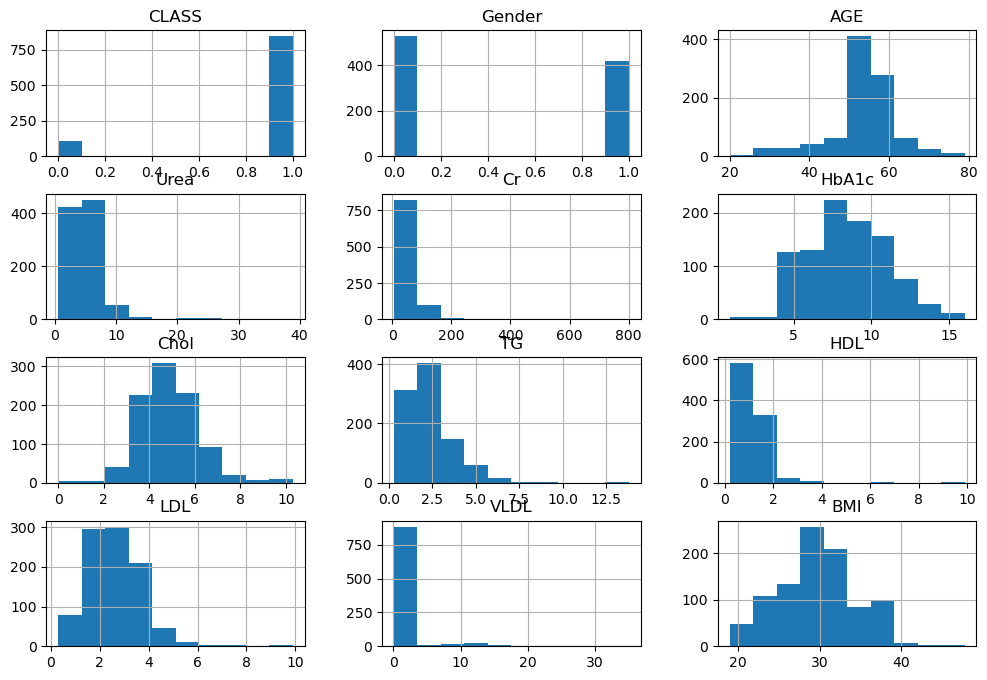

In [15]:
import matplotlib.pyplot as plt

df.hist(figsize=(12, 8)) # Check distributions
plt.show()

<Axes: >

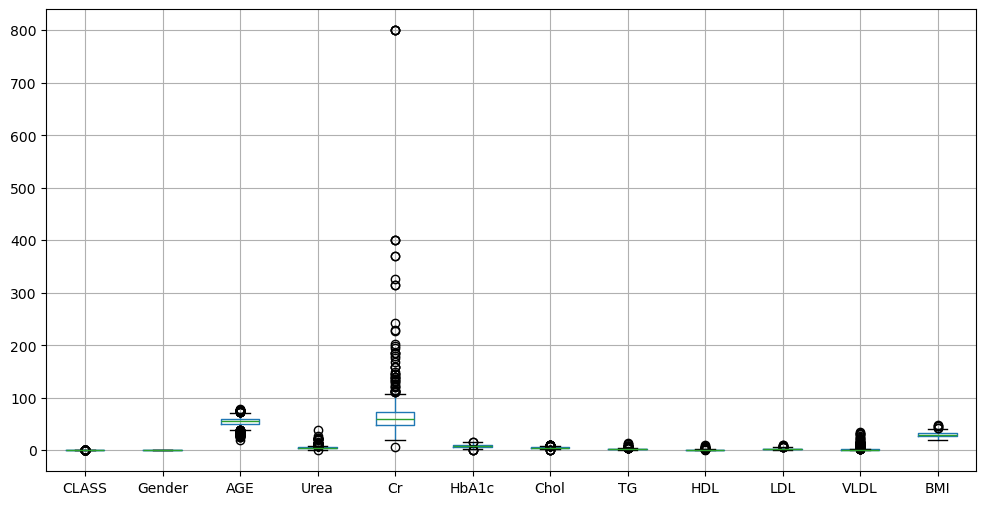

In [16]:
df.boxplot(figsize=(12, 6))

In [17]:
df['Cr'].sort_values(ascending=False).head()

846    800
860    800
273    800
283    800
590    401
Name: Cr, dtype: int64

In [18]:
df[df['Cr'] == 800]

,CLASS,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
273,1,0,58,20.8,800,9.1,6.6,2.9,1.1,4.3,1.3,33.0
283,1,0,58,20.8,800,9.1,6.6,2.9,1.1,4.3,1.3,33.0
846,1,0,56,20.8,800,9.0,4.6,2.0,1.2,2.5,0.9,35.0
860,1,0,60,20.8,800,9.0,2.3,1.1,0.9,0.9,0.5,33.0


In [19]:
df.columns[(df == 0).any()]

Index(['CLASS', 'Gender', 'Chol'], dtype='str')

In [20]:
df.columns[(df == 0.0).any()]

Index(['CLASS', 'Gender', 'Chol'], dtype='str')

In [21]:
df[df['Chol'] == 0.0]

,CLASS,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
99,0,0,77,5.0,106,5.4,0.0,2.8,0.8,1.8,0.7,19.0


In [22]:
df = df.drop(index=99)
df[df['Chol'] == 0.0]

,CLASS,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI


## Select and Train Model
We chose sklearn's LogisticRegression as our model. 

In [23]:
import numpy as np
from sklearn.model_selection import train_test_split
train, test_and_validate = train_test_split(df, test_size=0.2, random_state=42, stratify=df['CLASS'])

In [24]:
test, validate = train_test_split(test_and_validate, test_size=0.5, random_state=42, stratify=test_and_validate['CLASS'])

In [25]:
print(train.shape)
print(test.shape)
print(validate.shape)

(756, 12)
(95, 12)
(95, 12)


In [26]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression

# Separate features and target
X_train = train.drop(columns='CLASS')
y_train = train['CLASS']

X_validate = validate.drop(columns='CLASS')
y_validate = validate['CLASS']

X_test = test.drop(columns='CLASS')
y_test = test['CLASS']

# Scale features using only training data
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_validate_scaled = scaler.transform(X_validate)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Confusion Matrix

In [49]:
from sklearn.metrics import confusion_matrix
import pandas as pd

y_test_pred = model.predict(X_test_scaled)

matrix = confusion_matrix(y_test, y_test_pred)

df_confusion = pd.DataFrame(
    matrix, 
    index=['Predicted Normal', 'Predicted Abnormal'],
    columns=['Actual Normal', 'Actual Abnormal']
)

df_confusion

,Actual Normal,Actual Abnormal
Predicted Normal,9,1
Predicted Abnormal,2,83


Graphed the Confusion Matrix

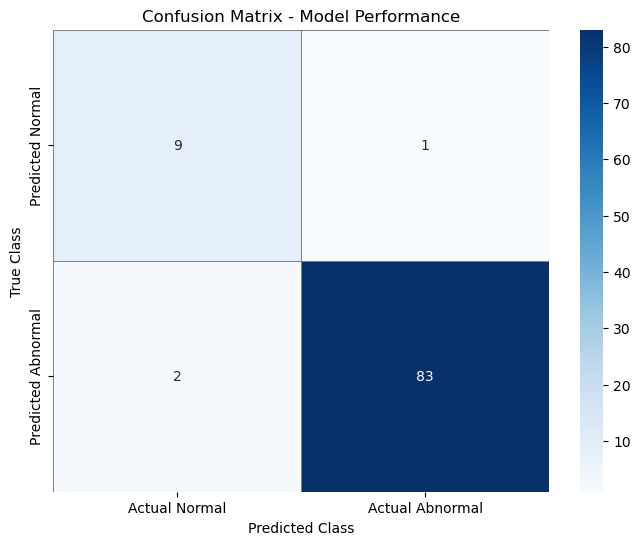

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(df_confusion, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            cbar=True,
            linewidths=.5,
            linecolor='gray') 

plt.title("Confusion Matrix - Model Performance")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

Extracted values from the Confusion Matrix

In [30]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

TN, FP, FN, TP = confusion_matrix(y_test, y_test_pred).ravel()

print(f"True Negative (TN) : {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"True Positive (TP) : {TP}")

True Negative (TN) : 9
False Positive (FP): 1
False Negative (FN): 2
True Positive (TP) : 83


In [31]:
# Sensitivity, hit rate, recall, or true positive rate
Sensitivity  = float(TP)/(TP+FN)*100
print(f"Sensitivity or TPR: {Sensitivity}%")  
print(f"There is a {Sensitivity}% chance of detecting patients with diabetes to actually have diabetes")

Sensitivity or TPR: 97.6470588235294%
There is a 97.6470588235294% chance of detecting patients with diabetes to actually have diabetes


In [32]:
# Specificity or true negative rate
Specificity  = float(TN)/(TN+FP)*100
print(f"Specificity or TNR: {Specificity}%") 
print(f"There is a {Specificity}% chance of detecting non-diabetic patients as non-diabetic.")

Specificity or TNR: 90.0%
There is a 90.0% chance of detecting non-diabetic patients as non-diabetic.


In [50]:
# Precision or positive predictive value
Precision = float(TP)/(TP+FP)*100
print(f"Precision: {Precision}%")  
print(f"You have diabetes, and the probablity of that is  {Precision}%")

Precision: 98.80952380952381%
You have diabetes, and the probablity of that is  98.80952380952381%


In [34]:
# Negative predictive value
NPV = float(TN)/(TN+FN)*100
print(f"Negative Predictive Value: {NPV}%") 
print(f"You don't have a diabetes, but there is a {NPV}% chance that is incorrect" )

Negative Predictive Value: 81.81818181818183%
You don't have a diabetes, but there is a 81.81818181818183% chance that is incorrect


In [35]:
# Fall out or false positive rate
FPR = float(FP)/(FP+TN)*100
print( f"False Positive Rate: {FPR}%") 
print( f"There is a {FPR}% chance that this positive result is incorrect.")

False Positive Rate: 10.0%
There is a 10.0% chance that this positive result is incorrect.


In [36]:
# False negative rate
FNR = float(FN)/(TP+FN)*100
print(f"False Negative Rate: {FNR}%") 
print(f"There is a {FNR}% chance that this negative result is incorrect.")

False Negative Rate: 2.3529411764705883%
There is a 2.3529411764705883% chance that this negative result is incorrect.


In [37]:
# False discovery rate
FDR = float(FP)/(TP+FP)*100
print(f"False Discovery Rate: {FDR}%" )
print(f"You have diabetes, but there is a {FDR}% chance this is incorrect.")

False Discovery Rate: 1.1904761904761905%
You have diabetes, but there is a 1.1904761904761905% chance this is incorrect.


In [38]:
# Overall accuracy
ACC = float(TP+TN)/(TP+FP+FN+TN)*100
print(f"Accuracy: {ACC}%") 

Accuracy: 96.84210526315789%


In [39]:
print(f"Sensitivity or TPR: {Sensitivity}%")    
print(f"Specificity or TNR: {Specificity}%") 
print(f"Precision: {Precision}%")   
print(f"Negative Predictive Value: {NPV}%")  
print( f"False Positive Rate: {FPR}%") 
print(f"False Negative Rate: {FNR}%")  
print(f"False Discovery Rate: {FDR}%" )
print(f"Accuracy: {ACC}%") 

Sensitivity or TPR: 97.6470588235294%
Specificity or TNR: 90.0%
Precision: 98.80952380952381%
Negative Predictive Value: 81.81818181818183%
False Positive Rate: 10.0%
False Negative Rate: 2.3529411764705883%
False Discovery Rate: 1.1904761904761905%
Accuracy: 96.84210526315789%


### AUC-ROC

In [40]:
y_test = test.iloc[:,0];
print("Validation AUC", roc_auc_score(y_test, y_test_pred))

Validation AUC 0.9382352941176472


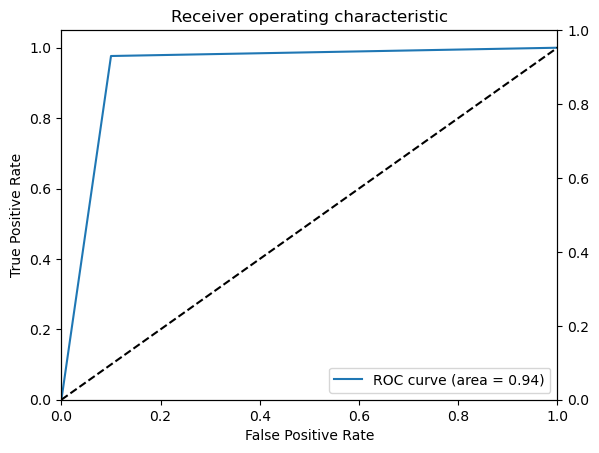

In [41]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming test_labels and target_predicted are defined

fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % (roc_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

ax2 = plt.gca().twinx()
# ax2.plot(fpr, thresholds, markeredgecolor='r', linestyle='dashed', color='r')
# ax2.set_ylabel('Threshold', color='r')
ax2.set_xlim([fpr[0], fpr[-1]])

plt.show()

## Tune Model
***Pending Tuning (most likely purely for project)***

## Deploy Model?